# RQ15 — Repeat Handling

## Research question

> How should the A/B repeated scans be used: one repeat only, both repeats as training data, or repeat-level score fusion at inference?

RQ12 showed that A and B deliberately reproduce the same start profile, direction and candidate order. They must therefore remain grouped across train/test boundaries. RQ14 then selected **Separate wheel × direction** modelling.

RQ15 changes only repeat handling.

### Fixed factors

- B01–B07 password-level LOPO;
- Current movement only;
- Absolute recovered 695-D feature representation;
- separate `wheel × direction` models;
- logistic regression `C = 0.10`;
- complete 10-candidate ranking;
- no identifier/order/digit metadata.

### Training variants

**Train-A**

Only A repetitions from the six training passwords are used to fit the model. The held-out password is still evaluated on both A and B.

**Train-B**

The symmetric B-only version.

**Train-A+B**

Both repeats are used for training. Held-out A and B remain separate decisions.

This is the RQ13/RQ14 Separate reference.

### Inference-time repeat fusion

For `Train-A+B`, the two held-out repeat scans from the same `profile × wheel × direction` are additionally fused.

The ten scores inside each A or B scan are first standardised to zero mean and unit standard deviation. Matching physical-digit scores are then averaged across A and B with equal weight and ranked once.

No fusion weight is tuned.

### Questions

1. Does the second repeat improve model fitting?
2. How consistent are the A/B top predictions?
3. Does an actual repeat measurement improve the final decision when the two score sets are fused?

## 1. Load B01–B07 and the frozen 695-D features

In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate completed RQ7 manifest."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_manifest.csv"
)

CACHE_DIR = (
    RESULTS_ROOT
    / "feature_cache"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "15_RQ15_Repeat_Handling"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCHES = [
    "B01_2085",
    "B02_4369",
    "B03_5720",
    "B04_6893",
    "B05_7246",
    "B06_8451",
    "B07_9638",
]

WHEELS = (
    1,
    2,
    4,
)

DIRECTIONS = (
    "CCW",
    "CW",
)

LOGREG_C = 0.10
RANDOM_STATE = 20260820

manifest = pd.read_csv(
    MANIFEST_PATH
)

if "row_id" not in manifest.columns:
    manifest[
        "row_id"
    ] = np.arange(
        len(
            manifest
        ),
        dtype=int,
    )

X = np.empty(
    (
        len(
            manifest
        ),
        695,
    ),
    dtype=np.float64,
)

for batch in BATCHES:
    cache = np.load(
        CACHE_DIR
        / f"{batch}_695d.npz",
        allow_pickle=False,
    )

    run_ids = cache[
        "run_ids"
    ].astype(
        str
    )

    features = cache[
        "features"
    ].astype(
        np.float64
    )

    index = {
        run_id: i
        for i, run_id
        in enumerate(
            run_ids
        )
    }

    batch_manifest = manifest[
        manifest[
            "batch"
        ]
        == batch
    ]

    rows = batch_manifest[
        "row_id"
    ].to_numpy(
        dtype=int
    )

    X[
        rows
    ] = np.vstack([
        features[
            index[
                run_id
            ]
        ]
        for run_id
        in batch_manifest[
            "run_id"
        ]
    ])

assert X.shape == (
    8400,
    695,
)

assert np.isfinite(
    X
).all()

print(
    "Decisions:",
    manifest[
        "decision_uid"
    ].nunique(),
)

print(
    "Candidates:",
    len(
        manifest
    ),
)

Mounted at /content/drive
Decisions: 840
Candidates: 8400


## 2. Common model and ranking helpers

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


def fit_domain_model(
    train_idx,
    test_idx,
):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X[
            train_idx
        ]
    )

    X_test = scaler.transform(
        X[
            test_idx
        ]
    )

    y_train = manifest.loc[
        train_idx,
        "y",
    ].to_numpy(
        dtype=int
    )

    model = LogisticRegression(
        C=LOGREG_C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    return model.decision_function(
        X_test
    )


def rank_decisions(
    part,
    model_name,
):
    rows = []

    for (
        decision_uid,
        group,
    ) in part.groupby(
        "decision_uid",
        sort=False,
    ):
        ranked = (
            group
            .sort_values(
                "score",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )

        true_digit = int(
            ranked[
                "true_digit"
            ].iloc[
                0
            ]
        )

        ranked_digits = (
            ranked[
                "to_digit"
            ]
            .astype(
                int
            )
            .tolist()
        )

        pred_digit = int(
            ranked_digits[
                0
            ]
        )

        true_rank = int(
            ranked_digits.index(
                true_digit
            )
            + 1
        )

        rows.append({
            "model": model_name,
            "heldout_batch": ranked[
                "batch"
            ].iloc[
                0
            ],
            "password": str(
                ranked[
                    "password"
                ].iloc[
                    0
                ]
            ),
            "decision_uid": decision_uid,
            "profile_id": ranked[
                "profile_id"
            ].iloc[
                0
            ],
            "wheel": int(
                ranked[
                    "wheel"
                ].iloc[
                    0
                ]
            ),
            "direction": ranked[
                "direction"
            ].iloc[
                0
            ],
            "repeat_id": ranked[
                "repeat_id"
            ].iloc[
                0
            ],
            "true_digit": true_digit,
            "pred_digit": pred_digit,
            "true_rank": true_rank,
            "top1": int(
                true_rank
                <= 1
            ),
            "top2": int(
                true_rank
                <= 2
            ),
            "top3": int(
                true_rank
                <= 3
            ),
            "reciprocal_rank": (
                1.0
                / true_rank
            ),
        })

    return pd.DataFrame(
        rows
    )


def metric_row(
    frame
):
    return {
        "n_decisions": len(
            frame
        ),
        "top1": frame[
            "top1"
        ].mean(),
        "top2": frame[
            "top2"
        ].mean(),
        "top3": frame[
            "top3"
        ].mean(),
        "mean_true_rank": frame[
            "true_rank"
        ].mean(),
        "median_true_rank": frame[
            "true_rank"
        ].median(),
        "mrr": frame[
            "reciprocal_rank"
        ].mean(),
        "macro_f1": f1_score(
            frame[
                "true_digit"
            ],
            frame[
                "pred_digit"
            ],
            labels=list(
                range(
                    10
                )
            ),
            average="macro",
            zero_division=0,
        ),
    }

## 3. A-only, B-only and A+B training

In [3]:
variant_specs = {
    "Train-A": (
        "A",
    ),
    "Train-B": (
        "B",
    ),
    "Train-A+B": (
        "A",
        "B",
    ),
}

decision_parts = []
candidate_score_parts = []

for (
    model_name,
    train_repeats,
) in variant_specs.items():
    for heldout in BATCHES:
        for wheel in WHEELS:
            for direction in DIRECTIONS:
                domain = (
                    manifest[
                        "wheel"
                    ].eq(
                        wheel
                    )
                    &
                    manifest[
                        "direction"
                    ].eq(
                        direction
                    )
                )

                train_mask = (
                    domain
                    &
                    manifest[
                        "batch"
                    ].ne(
                        heldout
                    )
                    &
                    manifest[
                        "repeat_id"
                    ].isin(
                        train_repeats
                    )
                )

                test_mask = (
                    domain
                    &
                    manifest[
                        "batch"
                    ].eq(
                        heldout
                    )
                )

                train_idx = manifest.index[
                    train_mask
                ].to_numpy()

                test_idx = manifest.index[
                    test_mask
                ].to_numpy()

                scores = fit_domain_model(
                    train_idx,
                    test_idx,
                )

                part = manifest.loc[
                    test_idx
                ].copy()

                part[
                    "score"
                ] = scores

                part[
                    "model"
                ] = model_name

                candidate_score_parts.append(
                    part
                )

                decision_parts.append(
                    rank_decisions(
                        part,
                        model_name,
                    )
                )


candidate_scores = pd.concat(
    candidate_score_parts,
    ignore_index=True,
)

decisions = pd.concat(
    decision_parts,
    ignore_index=True,
)

assert len(
    decisions
) == 2520

display(
    decisions.head()
)

,model,heldout_batch,password,decision_uid,profile_id,wheel,direction,repeat_id,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank
0,Train-A,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_W1_P01,1,CCW,A,2,2,1,1,1,1,1.000000
1,Train-A,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_W1_P01,1,CCW,B,2,2,1,1,1,1,1.000000
2,Train-A,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_W1_P02,1,CCW,A,2,1,3,0,0,1,0.333333
3,Train-A,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_B,B01_W1_P02,1,CCW,B,2,3,6,0,0,0,0.166667
4,Train-A,B01_2085,2085,B01_2085/B01_W1_P03_DSV1_MP2085_CCW_A,B01_W1_P03,1,CCW,A,2,2,1,1,1,1,1.000000


## 4. Fixed A/B score fusion

In [4]:
ab_scores = candidate_scores[
    candidate_scores[
        "model"
    ]
    == "Train-A+B"
].copy()

ab_scores[
    "score_z"
] = np.nan

for (
    decision_uid,
    idx,
) in ab_scores.groupby(
    "decision_uid"
).groups.items():
    idx = np.array(
        list(
            idx
        ),
        dtype=int,
    )

    values = ab_scores.loc[
        idx,
        "score",
    ].to_numpy(
        dtype=float
    )

    std = float(
        np.std(
            values
        )
    )

    scale = (
        std
        if std > 1e-12
        else 1.0
    )

    ab_scores.loc[
        idx,
        "score_z",
    ] = (
        values
        - np.mean(
            values
        )
    ) / scale


pair_keys = [
    "batch",
    "password",
    "profile_id",
    "wheel",
    "direction",
    "to_digit",
    "true_digit",
]

fused_candidates = (
    ab_scores.groupby(
        pair_keys,
        as_index=False,
    )
    .agg(
        fused_score=(
            "score_z",
            "mean",
        ),
        n_repeats=(
            "repeat_id",
            "nunique",
        ),
        y=(
            "y",
            "first",
        ),
    )
)

assert fused_candidates[
    "n_repeats"
].eq(
    2
).all()


fused_rows = []

for (
    batch,
    password,
    profile_id,
    wheel,
    direction,
), group in fused_candidates.groupby(
    [
        "batch",
        "password",
        "profile_id",
        "wheel",
        "direction",
    ],
    sort=False,
):
    ranked = (
        group
        .sort_values(
            "fused_score",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    true_digit = int(
        ranked[
            "true_digit"
        ].iloc[
            0
        ]
    )

    ranked_digits = (
        ranked[
            "to_digit"
        ]
        .astype(
            int
        )
        .tolist()
    )

    pred_digit = int(
        ranked_digits[
            0
        ]
    )

    true_rank = int(
        ranked_digits.index(
            true_digit
        )
        + 1
    )

    fused_rows.append({
        "model": (
            "A/B fused"
        ),
        "heldout_batch": batch,
        "password": str(
            password
        ),
        "profile_id": (
            profile_id
        ),
        "wheel": int(
            wheel
        ),
        "direction": (
            direction
        ),
        "true_digit": (
            true_digit
        ),
        "pred_digit": (
            pred_digit
        ),
        "true_rank": (
            true_rank
        ),
        "top1": int(
            true_rank
            <= 1
        ),
        "top2": int(
            true_rank
            <= 2
        ),
        "top3": int(
            true_rank
            <= 3
        ),
        "reciprocal_rank": (
            1.0
            / true_rank
        ),
    })


fused = pd.DataFrame(
    fused_rows
)

assert len(
    fused
) == 420

display(
    fused.head()
)

,model,heldout_batch,password,profile_id,wheel,direction,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank
0,A/B fused,B01_2085,2085,B01_W1_P01,1,CCW,2,2,1,1,1,1,1.000000
1,A/B fused,B01_2085,2085,B01_W1_P01,1,CW,2,2,1,1,1,1,1.000000
2,A/B fused,B01_2085,2085,B01_W1_P02,1,CCW,2,1,5,0,0,0,0.200000
3,A/B fused,B01_2085,2085,B01_W1_P02,1,CW,2,1,3,0,0,1,0.333333
4,A/B fused,B01_2085,2085,B01_W1_P03,1,CCW,2,2,1,1,1,1,1.000000


## 5. Matched repeat-pair audit

In [5]:
ab_decisions = decisions[
    decisions[
        "model"
    ]
    == "Train-A+B"
].copy()


pair_wide = (
    ab_decisions.pivot(
        index=[
            "heldout_batch",
            "password",
            "profile_id",
            "wheel",
            "direction",
            "true_digit",
        ],
        columns="repeat_id",
        values=[
            "pred_digit",
            "top1",
            "true_rank",
        ],
    )
)

pair_wide.columns = [
    f"{metric}_{repeat_id}"
    for (
        metric,
        repeat_id,
    ) in pair_wide.columns
]

pair_wide = pair_wide.reset_index()

pair_wide[
    "prediction_agreement"
] = (
    pair_wide[
        "pred_digit_A"
    ]
    == pair_wide[
        "pred_digit_B"
    ]
)

pair_wide[
    "both_correct"
] = (
    (
        pair_wide[
            "top1_A"
        ]
        == 1
    )
    &
    (
        pair_wide[
            "top1_B"
        ]
        == 1
    )
)

pair_wide[
    "one_correct"
] = (
    pair_wide[
        "top1_A"
    ]
    + pair_wide[
        "top1_B"
    ]
    == 1
)

pair_wide[
    "both_wrong"
] = (
    (
        pair_wide[
            "top1_A"
        ]
        == 0
    )
    &
    (
        pair_wide[
            "top1_B"
        ]
        == 0
    )
)

pair_outcomes = pd.DataFrame([
    {
        "outcome": (
            "Both correct"
        ),
        "n_pairs": int(
            pair_wide[
                "both_correct"
            ].sum()
        ),
    },
    {
        "outcome": (
            "One correct"
        ),
        "n_pairs": int(
            pair_wide[
                "one_correct"
            ].sum()
        ),
    },
    {
        "outcome": (
            "Both wrong"
        ),
        "n_pairs": int(
            pair_wide[
                "both_wrong"
            ].sum()
        ),
    },
])

pair_outcomes[
    "rate"
] = (
    pair_outcomes[
        "n_pairs"
    ]
    / len(
        pair_wide
    )
)

print(
    "A/B top prediction agreement:",
    f"{100 * pair_wide['prediction_agreement'].mean():.1f}%",
)

display(
    pair_outcomes
)

A/B top prediction agreement: 67.6%


,outcome,n_pairs,rate
0,Both correct,274,0.652381
1,One correct,112,0.266667
2,Both wrong,34,0.080952


## 6. Summary and password-level tests

In [6]:
from scipy.stats import wilcoxon

summary_rows = []

for (
    model_name,
    group,
) in decisions.groupby(
    "model",
    sort=False,
):
    summary_rows.append({
        "scope": (
            "Overall"
        ),
        "model": (
            model_name
        ),
        **metric_row(
            group
        ),
    })

    for wheel in WHEELS:
        summary_rows.append({
            "scope": (
                f"W{wheel}"
            ),
            "model": (
                model_name
            ),
            **metric_row(
                group[
                    group[
                        "wheel"
                    ]
                    == wheel
                ]
            ),
        })

    for test_repeat in [
        "A",
        "B",
    ]:
        summary_rows.append({
            "scope": (
                f"Test-{test_repeat}"
            ),
            "model": (
                model_name
            ),
            **metric_row(
                group[
                    group[
                        "repeat_id"
                    ]
                    == test_repeat
                ]
            ),
        })


summary_rows.append({
    "scope": "Overall",
    "model": "A/B fused",
    **metric_row(
        fused
    ),
})

for wheel in WHEELS:
    summary_rows.append({
        "scope": (
            f"W{wheel}"
        ),
        "model": (
            "A/B fused"
        ),
        **metric_row(
            fused[
                fused[
                    "wheel"
                ]
                == wheel
            ]
        ),
    })


summary = pd.DataFrame(
    summary_rows
)


password_rows = []

for (
    model_name,
    group,
) in decisions.groupby(
    "model",
    sort=False,
):
    for (
        heldout_batch,
        password,
    ), pg in group.groupby(
        [
            "heldout_batch",
            "password",
        ],
        sort=False,
    ):
        password_rows.append({
            "model": model_name,
            "heldout_batch": (
                heldout_batch
            ),
            "password": str(
                password
            ),
            **metric_row(
                pg
            ),
        })


for (
    heldout_batch,
    password,
), pg in fused.groupby(
    [
        "heldout_batch",
        "password",
    ],
    sort=False,
):
    password_rows.append({
        "model": (
            "A/B fused"
        ),
        "heldout_batch": (
            heldout_batch
        ),
        "password": str(
            password
        ),
        **metric_row(
            pg
        ),
    })


password_summary = pd.DataFrame(
    password_rows
)


password_wide = (
    password_summary.pivot(
        index=[
            "heldout_batch",
            "password",
        ],
        columns="model",
        values="top1",
    )
    .reset_index()
)


test_rows = []

for comparator in [
    "Train-A",
    "Train-B",
]:
    delta = (
        password_wide[
            "Train-A+B"
        ]
        - password_wide[
            comparator
        ]
    )

    test = wilcoxon(
        password_wide[
            "Train-A+B"
        ],
        password_wide[
            comparator
        ],
        alternative="two-sided",
        method="auto",
    )

    test_rows.append({
        "comparison": (
            f"Train-A+B vs "
            f"{comparator}"
        ),
        "n_passwords": 7,
        "mean_delta_pp": float(
            100
            * delta.mean()
        ),
        "median_delta_pp": float(
            100
            * delta.median()
        ),
        "p_two_sided": float(
            test.pvalue
        ),
    })


fusion_delta = (
    password_wide[
        "A/B fused"
    ]
    - password_wide[
        "Train-A+B"
    ]
)

fusion_test = wilcoxon(
    password_wide[
        "A/B fused"
    ],
    password_wide[
        "Train-A+B"
    ],
    alternative="greater",
    method="auto",
)

test_rows.append({
    "comparison": (
        "A/B fused vs "
        "Train-A+B individual decisions"
    ),
    "n_passwords": 7,
    "mean_delta_pp": float(
        100
        * fusion_delta.mean()
    ),
    "median_delta_pp": float(
        100
        * fusion_delta.median()
    ),
    "p_one_sided_fusion_better": float(
        fusion_test.pvalue
    ),
})


tests = pd.DataFrame(
    test_rows
)

display(
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ].round(
        4
    )
)

display(
    tests.round(
        4
    )
)

,scope,model,n_decisions,top1,top2,top3,mean_true_rank,median_true_rank,mrr,macro_f1
0,Overall,Train-A,840,0.7536,0.8917,0.9405,1.4798,1.0,0.8513,0.7496
6,Overall,Train-B,840,0.7417,0.8631,0.9155,1.5940,1.0,0.8368,0.7391
12,Overall,Train-A+B,840,0.7857,0.9036,0.9548,1.4048,1.0,0.8712,0.7809
18,Overall,A/B fused,420,0.8595,0.9548,0.9786,1.2286,1.0,0.9195,0.8601


,comparison,n_passwords,mean_delta_pp,median_delta_pp,p_two_sided,p_one_sided_fusion_better
0,Train-A+B vs Train-A,7,3.2143,2.5000,0.1250,NaN
1,Train-A+B vs Train-B,7,4.4048,4.1667,0.0312,NaN
2,A/B fused vs Train-A+B individual decisions,7,7.3810,6.6667,NaN,0.0078


## 7. Main figures

In [7]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
PALE_BLUE = "#DCE8F0"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

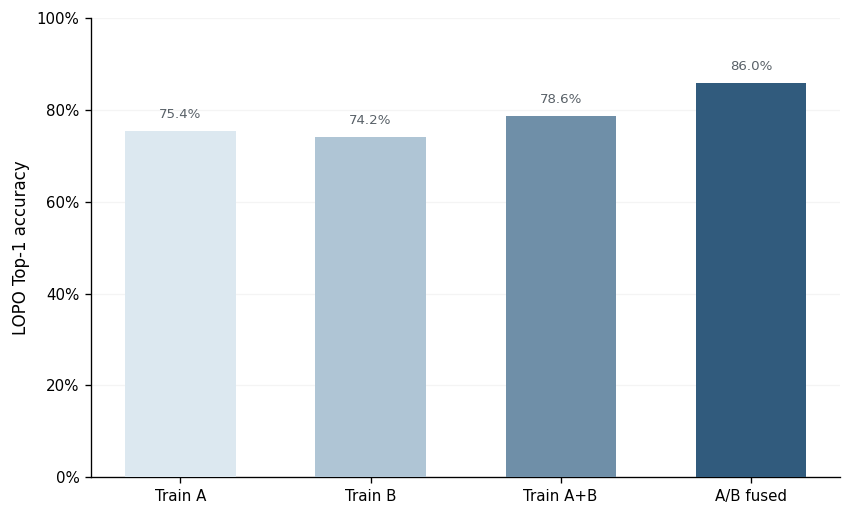

In [8]:
# Figure 1 — overall repeat handling.

overall_plot = (
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ]
    .set_index(
        "model"
    )
    .reindex([
        "Train-A",
        "Train-B",
        "Train-A+B",
        "A/B fused",
    ])
)

fig, ax = plt.subplots(
    figsize=(
        7.2,
        4.4,
    )
)

x = np.arange(
    len(
        overall_plot
    )
)

values = (
    100
    * overall_plot[
        "top1"
    ].to_numpy()
)

bars = ax.bar(
    x,
    values,
    width=0.58,
    color=[
        PALE_BLUE,
        LIGHT_BLUE,
        MID_BLUE,
        DARK_BLUE,
    ],
    edgecolor="none",
    zorder=3,
)

for (
    bar,
    value,
) in zip(
    bars,
    values,
):
    ax.annotate(
        f"{value:.1f}%",
        xy=(
            bar.get_x()
            + bar.get_width()
            / 2,
            bar.get_height(),
        ),
        xytext=(
            0,
            6,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK_GREY,
    )


ax.set_xticks(
    x
)

ax.set_xticklabels([
    "Train A",
    "Train B",
    "Train A+B",
    "A/B fused",
])

ax.set_ylabel(
    "LOPO Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ15_Fig1_repeat_handling_top1",
)

plt.show()

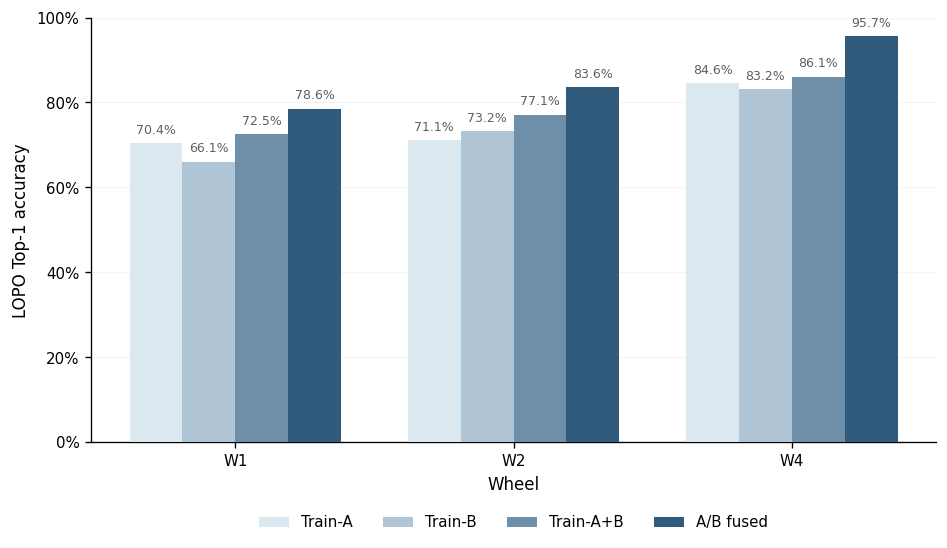

In [9]:
# Figure 2 — wheel-level grouped comparison.

wheel_summary = (
    summary[
        summary[
            "scope"
        ].isin([
            "W1",
            "W2",
            "W4",
        ])
    ]
)

wheel_plot = (
    wheel_summary.pivot(
        index="scope",
        columns="model",
        values="top1",
    )
    .reindex(
        index=[
            "W1",
            "W2",
            "W4",
        ],
        columns=[
            "Train-A",
            "Train-B",
            "Train-A+B",
            "A/B fused",
        ],
    )
)

fig, ax = plt.subplots(
    figsize=(
        8.0,
        4.6,
    )
)

x = np.arange(
    3
)

width = 0.19

models = [
    "Train-A",
    "Train-B",
    "Train-A+B",
    "A/B fused",
]

offsets = (
    np.arange(
        len(
            models
        )
    )
    - (
        len(
            models
        )
        - 1
    )
    / 2
) * width

color_map = {
    "Train-A": PALE_BLUE,
    "Train-B": LIGHT_BLUE,
    "Train-A+B": MID_BLUE,
    "A/B fused": DARK_BLUE,
}

for (
    offset,
    model,
) in zip(
    offsets,
    models,
):
    values = (
        100
        * wheel_plot[
            model
        ].to_numpy()
    )

    bars = ax.bar(
        x
        + offset,
        values,
        width=width,
        color=color_map[
            model
        ],
        edgecolor="none",
        label=model,
        zorder=3,
    )

    for (
        bar,
        value,
    ) in zip(
        bars,
        values,
    ):
        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                bar.get_height(),
            ),
            xytext=(
                0,
                4,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=DARK_GREY,
        )


ax.set_xticks(
    x
)

ax.set_xticklabels([
    "W1",
    "W2",
    "W4",
])

ax.set_xlabel(
    "Wheel"
)

ax.set_ylabel(
    "LOPO Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.14,
    ),
)

fig.subplots_adjust(
    bottom=0.22
)

fig.tight_layout()

save_figure(
    fig,
    "RQ15_Fig2_wheel_repeat_handling",
)

plt.show()

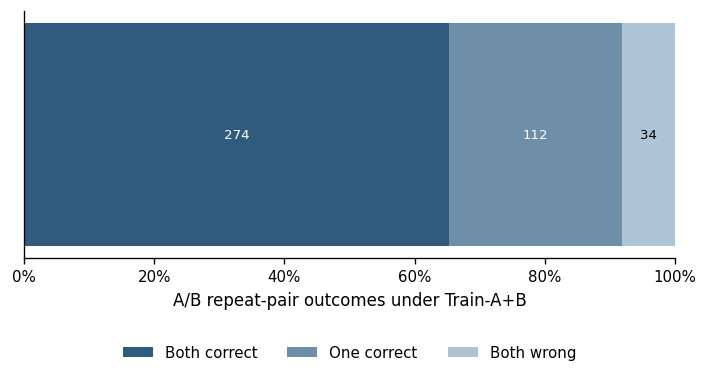

In [10]:
# Figure 3 — matched A/B outcome composition under Train-A+B.

outcome_order = [
    "Both correct",
    "One correct",
    "Both wrong",
]

outcome_counts = (
    pair_outcomes
    .set_index(
        "outcome"
    )
    .reindex(
        outcome_order
    )
)

fig, ax = plt.subplots(
    figsize=(
        7.0,
        3.6,
    )
)

left = 0.0

for (
    outcome,
    color,
) in zip(
    outcome_order,
    [
        DARK_BLUE,
        MID_BLUE,
        LIGHT_BLUE,
    ],
):
    rate = float(
        outcome_counts.loc[
            outcome,
            "rate",
        ]
    )

    count = int(
        outcome_counts.loc[
            outcome,
            "n_pairs",
        ]
    )

    ax.barh(
        [
            0
        ],
        [
            100
            * rate
        ],
        left=left,
        height=0.45,
        color=color,
        edgecolor="none",
        label=outcome,
    )

    if rate >= 0.08:
        ax.text(
            left
            + 50
            * rate,
            0,
            f"{count}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if outcome
                != "Both wrong"
                else "black"
            ),
        )

    left += (
        100
        * rate
    )


ax.set_yticks([])

ax.set_xlabel(
    "A/B repeat-pair outcomes under Train-A+B"
)

ax.set_xlim(
    0,
    100,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: (
            f"{x:.0f}%"
        )
    )
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.30,
    ),
)

fig.subplots_adjust(
    bottom=0.31
)

save_figure(
    fig,
    "RQ15_Fig3_repeat_pair_outcomes",
)

plt.show()

## 8. Tables and result record

In [11]:
candidate_scores.to_csv(
    RESULT_DIR
    / "RQ15_candidate_scores.csv",
    index=False,
)

decisions.to_csv(
    RESULT_DIR
    / "RQ15_decision_predictions.csv",
    index=False,
)

fused_candidates.to_csv(
    RESULT_DIR
    / "RQ15_fused_candidate_scores.csv",
    index=False,
)

fused.to_csv(
    RESULT_DIR
    / "RQ15_fused_decisions.csv",
    index=False,
)

pair_wide.to_csv(
    RESULT_DIR
    / "RQ15_repeat_pair_audit.csv",
    index=False,
)

pair_outcomes.to_csv(
    RESULT_DIR
    / "RQ15_pair_outcomes.csv",
    index=False,
)

summary.to_csv(
    RESULT_DIR
    / "RQ15_summary_metrics.csv",
    index=False,
)

password_summary.to_csv(
    RESULT_DIR
    / "RQ15_password_summary.csv",
    index=False,
)

tests.to_csv(
    RESULT_DIR
    / "RQ15_password_level_tests.csv",
    index=False,
)


table1 = (
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ]
    .set_index(
        "model"
    )
    .reindex([
        "Train-A",
        "Train-B",
        "Train-A+B",
        "A/B fused",
    ])
    .reset_index()
)

for (
    src,
    dst,
) in [
    (
        "top1",
        "Top-1",
    ),
    (
        "top2",
        "Top-2",
    ),
    (
        "top3",
        "Top-3",
    ),
]:
    table1[
        dst
    ] = (
        100
        * table1[
            src
        ]
    ).map(
        lambda x: f"{x:.1f}%"
    )


table1[
    "Mean rank"
] = table1[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table1 = table1[
    [
        "model",
        "n_decisions",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
    ]
].rename(
    columns={
        "model": (
            "Repeat handling"
        ),
        "n_decisions": (
            "N decisions"
        ),
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ15_Table1_repeat_handling.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ15_Table1_repeat_handling.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    tests
)

,Repeat handling,N decisions,Top-1,Top-2,Top-3,Mean rank
0,Train-A,840,75.4%,89.2%,94.0%,1.48
1,Train-B,840,74.2%,86.3%,91.5%,1.59
2,Train-A+B,840,78.6%,90.4%,95.5%,1.40
3,A/B fused,420,86.0%,95.5%,97.9%,1.23


,comparison,n_passwords,mean_delta_pp,median_delta_pp,p_two_sided,p_one_sided_fusion_better
0,Train-A+B vs Train-A,7,3.214286,2.500000,0.12500,NaN
1,Train-A+B vs Train-B,7,4.404762,4.166667,0.03125,NaN
2,A/B fused vs Train-A+B individual decisions,7,7.380952,6.666667,NaN,0.007812


In [12]:
overall_models = (
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ]
    .set_index(
        "model"
    )
)

train_a_top1 = float(
    overall_models.loc[
        "Train-A",
        "top1",
    ]
)

train_b_top1 = float(
    overall_models.loc[
        "Train-B",
        "top1",
    ]
)

train_ab_top1 = float(
    overall_models.loc[
        "Train-A+B",
        "top1",
    ]
)

fused_top1 = float(
    overall_models.loc[
        "A/B fused",
        "top1",
    ]
)

agreement_rate = float(
    pair_wide[
        "prediction_agreement"
    ].mean()
)


conclusion = {
    "research_question": (
        "How should A/B repeated scans be used: one repeat only, both repeats "
        "for training, or repeat-level score fusion at inference?"
    ),
    "analysis_type": (
        "Controlled repeat-handling ablation under fixed Separate wheel × direction LOPO"
    ),
    "overall": {
        "Train_A_top1": (
            train_a_top1
        ),
        "Train_B_top1": (
            train_b_top1
        ),
        "Train_AB_top1": (
            train_ab_top1
        ),
        "AB_fused_top1": (
            fused_top1
        ),
        "repeat_prediction_agreement": (
            agreement_rate
        ),
    },
    "password_level_tests": (
        tests.to_dict(
            orient="records"
        )
    ),
    "pair_outcomes": (
        pair_outcomes.to_dict(
            orient="records"
        )
    ),
    "interpretation": (
        f"Training on A only gives {100 * train_a_top1:.1f}% Top-1, training on B only "
        f"gives {100 * train_b_top1:.1f}%, and using both repeats in training gives "
        f"{100 * train_ab_top1:.1f}%. A/B top predictions agree on "
        f"{100 * agreement_rate:.1f}% of matched repeat pairs. Equal-weight score fusion "
        f"after within-scan score normalisation gives {100 * fused_top1:.1f}% pair-level Top-1."
    ),
    "limitation": (
        "Fusion uses no tuned weight and yields one pair-level decision rather than two "
        "repeat-level decisions; password-level comparison is therefore the primary inference."
    ),
    "selected_training": "Train-A+B",
    "selected_inference": (
        "A/B fused when a matched repeat is available; "
        "single-scan ranking otherwise."
    ),
    "decision": (
        "Select A+B for model training. The combined training set gives the strongest "
        "single-scan reference. When a matched A/B repeat is available at inference, "
        "use the fixed equal-weight score fusion after within-scan score normalisation. "
        "If no repeat is available, fall back to the ordinary single-scan ranking."
    ),
    "next_step": (
        "The next controlled ablation tests target/contact, reference/motor and dual-channel "
        "feature use under the selected direction and repeat treatment."
    ),
}

with open(
    RESULT_DIR
    / "RQ15_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "15_RQ15_Repeat_Handling.ipynb"
    ),
    "source": (
        "B01-B07 frozen 695-D feature caches + RQ7 candidate manifest"
    ),
    "direction_treatment": (
        "Separate wheel × direction models fixed from RQ14"
    ),
    "C": LOGREG_C,
    "training_variants": [
        "Train-A",
        "Train-B",
        "Train-A+B",
    ],
    "fusion": (
        "Per-scan candidate score z-normalisation followed by equal A/B mean by physical digit"
    ),
    "primary_metric": (
        "Password-grouped LOPO Top-1"
    ),
}


with open(
    RESULT_DIR
    / "RQ15_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ15_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "How should A/B repeated scans be used: one repeat only, both repeats for training, or repeat-level score fusion at inference?",
  "analysis_type": "Controlled repeat-handling ablation under fixed Separate wheel \u00d7 direction LOPO",
  "overall": {
    "Train_A_top1": 0.7535714285714286,
    "Train_B_top1": 0.7416666666666667,
    "Train_AB_top1": 0.7857142857142857,
    "AB_fused_top1": 0.8595238095238096,
    "repeat_prediction_agreement": 0.6761904761904762
  },
  "password_level_tests": [
    {
      "comparison": "Train-A+B vs Train-A",
      "n_passwords": 7,
      "mean_delta_pp": 3.214285714285714,
      "median_delta_pp": 2.500000000000002,
      "p_two_sided": 0.125,
      "p_one_sided_fusion_better": NaN
    },
    {
      "comparison": "Train-A+B vs Train-B",
      "n_passwords": 7,
      "mean_delta_pp": 4.4047619047619015,
      "median_delta_pp": 4.1666666666666625,
      "p_two_sided": 0.03125,
      "p_one_sided_fusion_better": NaN
    },
   